In [20]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [21]:
# Load dataset
breast_cancer_data = load_breast_cancer()
breast_cancer_df = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)
print(breast_cancer_df.head())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [22]:

print(breast_cancer_data.data[0])
print(breast_cancer_data.feature_names)
print(breast_cancer_data.target)
print(breast_cancer_data.target_names)

[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1

In [23]:
# Split data
training_data, validation_data, training_labels, validation_labels = train_test_split(
    breast_cancer_data.data,
    breast_cancer_data.target,
    test_size=0.2,
    random_state=42
)

In [24]:
print("Length of Training Data:", len(training_data))
print("Length of Training Labels:", len(training_labels))
print("Length of Validation Data:", len(validation_data))
print("Length of Validation Labels:", len(validation_labels))

Length of Training Data: 455
Length of Training Labels: 455
Length of Validation Data: 114
Length of Validation Labels: 114


In [25]:
# Compute validation accuracies for k = 1 to 100
accuracies = []
for k in range(1, 101):
    classifier = KNeighborsClassifier(n_neighbors=k)   # ✅ fixed here
    classifier.fit(training_data, training_labels)
    accuracy = classifier.score(validation_data, validation_labels)
    accuracies.append(accuracy)

In [26]:
# Find best k
best_accuracy = max(accuracies)
best_k = accuracies.index(best_accuracy) + 1
print("Best k:", best_k, "with accuracy:", best_accuracy)

Best k: 11 with accuracy: 0.9824561403508771


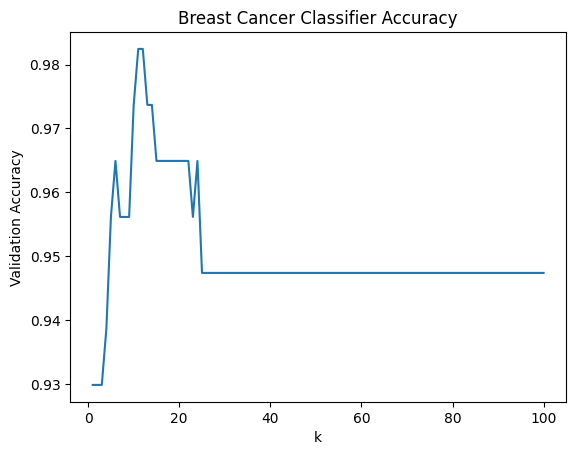

In [27]:
# Plot results
k_list = range(1, 101)
plt.plot(k_list, accuracies)
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("Breast Cancer Classifier Accuracy")
plt.show()